# Random Forest Baseline

This notebook tracks a clean Random Forest baseline and a validation-only random search using the **same finalized feature set** as the frozen logistic model. The tuning sections are validation-only; the later final section reports the already-frozen hold-out test evaluation.

Like the other modeling notebooks, this workflow now assumes the audited post-2009 cutoff. The Random Forest family is trained and evaluated only on fights dated `2010-01-01` or later because earlier rows do not appear to preserve a stable red/blue target convention.



In [1]:
from pathlib import Path
import json
import pandas as pd

repo_root = Path.cwd()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
outputs_dir = repo_root / 'outputs'


## Why Random Search

The Random Forest search space is large enough that exhaustive grid search would be expensive and mostly wasteful. Random search is a good fit here because it covers a wider mix of parameter combinations with fewer runs, while still keeping everything validation-only.


In [2]:
rf_baseline = json.loads((outputs_dir / 'random_forest_baseline_validation.json').read_text())
rf_random_search = pd.read_csv(outputs_dir / 'random_forest_random_search_results.csv')
rf_best = json.loads((outputs_dir / 'best_random_forest_random_search.json').read_text())
rf_importance = pd.read_csv(outputs_dir / 'random_forest_random_search_feature_importance.csv')


## Random Forest Baseline

This is the simple untuned forest used as the starting point.


In [3]:
pd.DataFrame([rf_baseline['validation_metrics']])


,log_loss,roc_auc,brier_score,accuracy
0,0.680929,0.614647,0.243385,0.592708


## Top 10 Random Search Configurations

These are ranked by validation log loss, with ROC AUC used as a tie-breaker.


In [4]:
rf_random_search.head(10)


,iteration,log_loss,roc_auc,brier_score,accuracy,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,criterion,class_weight,bootstrap
0,100,0.667603,0.611137,0.237246,0.605120,800,2,1,0.3,12.0,log_loss,balanced_subsample,True
1,50,0.667969,0.611442,0.237438,0.605896,1200,2,2,log2,12.0,entropy,balanced_subsample,True
2,14,0.668036,0.614978,0.237540,0.606672,200,10,2,0.3,10.0,gini,balanced_subsample,True
3,3,0.668148,0.618954,0.237695,0.602793,200,50,1,0.3,8.0,log_loss,balanced_subsample,True
4,31,0.668273,0.615941,0.237754,0.606672,300,2,5,sqrt,8.0,gini,balanced,True
5,83,0.668523,0.616098,0.237861,0.605120,800,10,5,sqrt,8.0,entropy,balanced_subsample,True
6,41,0.668539,0.615953,0.237887,0.605120,500,2,5,sqrt,8.0,log_loss,balanced_subsample,True
7,35,0.668909,0.613016,0.237990,0.603569,300,5,5,log2,10.0,entropy,balanced,True
8,30,0.668961,0.617387,0.238103,0.608999,800,2,5,log2,6.0,entropy,balanced_subsample,True
9,79,0.669213,0.616344,0.238230,0.605120,1200,5,10,0.3,6.0,log_loss,balanced,True


## Tuned RF vs Baseline RF vs Logistic Benchmark

The comparison in this section is validation-only. The later final section reports hold-out test metrics for the frozen model families, but those results are not used for tuning here.


In [5]:
comparison = pd.DataFrame([
    {'model': 'rf_baseline', **rf_baseline['validation_metrics']},
    {'model': 'rf_tuned_best', **rf_best['best_validation_metrics']},
    {'model': 'logistic_validation_benchmark', **rf_best['logistic_validation_benchmark']},
])
comparison


,model,log_loss,roc_auc,brier_score,accuracy
0,rf_baseline,0.680929,0.614647,0.243385,0.592708
1,rf_tuned_best,0.667603,0.611137,0.237246,0.605120
2,logistic_validation_benchmark,0.662819,0.642413,0.235524,0.605896


## Best RF Parameters And Feature Importance

Feature importance here is model-specific and not causal, but it gives a useful ranking of which inputs the tuned forest relied on most.


In [6]:
rf_best['best_parameters']


{'n_estimators': 800,
 'min_samples_split': 2,
 'min_samples_leaf': 1,
 'max_features': 0.3,
 'max_depth': 12,
 'criterion': 'log_loss',
 'class_weight': 'balanced_subsample',
 'bootstrap': True}

In [7]:
rf_importance.head(12)


,feature,importance
0,diff_sig_strike_accuracy,0.134958
1,diff_age,0.116246
2,diff_td_landed_per_fight,0.115150
3,diff_avg_fight_duration_seconds,0.109063
4,diff_kd_absorbed_per_fight,0.085818
5,diff_decision_rate,0.083402
6,diff_reach,0.081495
7,diff_total_losses,0.069560
8,diff_total_wins,0.066032
9,diff_win_streak,0.050657


## Validation-Only Note

The Random Forest baseline and random-search tuning were done without using the hold-out test set. The final test section below is a one-time benchmark report on the validation-selected frozen forest.


## Final Random Forest Test Evaluation

The best validation-selected Random Forest has now been fit on train+validation and evaluated once on the hold-out test set. No further tuning should be done from these test results.

This frozen benchmark therefore reflects the post-2009 modeling universe, not the full raw UFC history table.



In [8]:
rf_final = json.loads((outputs_dir / 'final_random_forest_test_metrics.json').read_text())
rf_final


{'feature_names': ['diff_age', 'diff_total_wins', 'diff_total_losses', 'diff_win_streak', 'diff_td_landed_per_fight', 'diff_kd_absorbed_per_fight', 'diff_reach', 'diff_sig_strike_accuracy', 'diff_avg_fight_duration_seconds', 'diff_decision_rate', 'pre_fight_red_late_finish_rate', 'diff_five_round_experience'], 'model_params': {'n_estimators': 800, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 0.3, 'max_depth': 12, 'criterion': 'log_loss', 'class_weight': 'balanced_subsample', 'bootstrap': True}, 'test_metrics': {'log_loss': 0.6597555194860298, 'roc_auc': 0.6450525145336541, 'brier_score': 0.2337728642201258, 'accuracy': 0.6043290043290044, 'precision': 0.6226685796269728, 'recall': 0.6910828025477707, 'f1': 0.6550943396226415}, 'confusion_matrix': {'labels': [0, 1], 'matrix': [[264, 263], [194, 434]], 'tn': 264, 'fp': 263, 'fn': 194, 'tp': 434}}

In [9]:
final_model_comparison = pd.read_csv(outputs_dir / 'final_model_test_comparison.csv')
final_model_comparison


            model_name  ...                                              notes
0  logistic_regression  ...  Best log loss on test. Best ROC AUC on test. B...
1        random_forest  ...                             Best accuracy on test.
2              xgboost  ...  Highest recall on test. Weakest overall probab...

[3 rows x 14 columns]

In [10]:
rf_calibration = pd.read_csv(outputs_dir / 'final_random_forest_calibration_table.csv')
rf_importance_final = pd.read_csv(outputs_dir / 'final_random_forest_feature_importance.csv')
rf_calibration


,probability_bin,rows,mean_predicted_probability,observed_red_win_rate
0,0,129,0.349566,0.364341
1,1,129,0.425684,0.387597
2,2,129,0.465866,0.457364
3,3,129,0.504039,0.519380
4,4,129,0.538600,0.573643
5,5,128,0.564817,0.593750
6,6,129,0.590759,0.589147
7,7,129,0.622687,0.635659
8,8,129,0.655433,0.627907
9,9,129,0.724128,0.705426


In [11]:
rf_importance_final.head(12)


,feature,importance
0,diff_sig_strike_accuracy,0.135913
1,diff_td_landed_per_fight,0.116599
2,diff_age,0.113671
3,diff_avg_fight_duration_seconds,0.108680
4,diff_kd_absorbed_per_fight,0.088291
5,diff_decision_rate,0.083670
6,diff_total_losses,0.074857
7,diff_reach,0.071960
8,diff_total_wins,0.065718
9,diff_win_streak,0.052560


## Final Random Forest Visual

This plot shows which inputs the frozen Random Forest relied on most on the final feature set. Importances are relative and model-specific, not causal.


In [12]:
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

repo_root = Path.cwd()
if repo_root.name == 'notebooks':
    repo_root = repo_root.parent
figures_dir = repo_root / 'outputs' / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)
rf_importance_final = pd.read_csv(repo_root / 'outputs' / 'final_random_forest_feature_importance.csv')


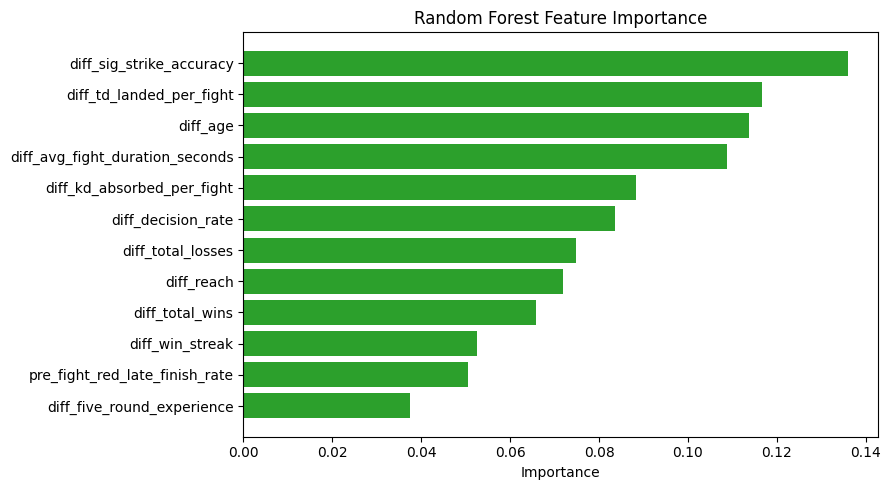

In [13]:
plot_df = rf_importance_final.head(12).sort_values('importance')
fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(plot_df['feature'], plot_df['importance'], color='tab:green')
ax.set_title('Random Forest Feature Importance')
ax.set_xlabel('Importance')
fig.tight_layout()
fig.savefig(figures_dir / '04_random_forest_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## Walk-Forward Calibration And Market Benchmark

After freezing the Random Forest family, the next research step was not more hold-out tuning. Instead, the repo adds a separate pre-test walk-forward workflow that uses the frozen final feature set and the validation-selected Random Forest configuration to compare raw probabilities, calibrated probabilities, market no-vig probabilities, and model-market blends.


In [ ]:
walk_forward_comparison = pd.read_csv(outputs_dir / "walk_forward_model_comparison.csv")
walk_forward_comparison


### Random Forest Probability Variants

This view focuses on the Random Forest variants only. Lower log loss and Brier score are better, while higher ROC AUC is better.


In [ ]:
import matplotlib.pyplot as plt

rf_walk_forward = walk_forward_comparison[walk_forward_comparison["model_name"].isin([
    "rf_raw",
    "rf_sigmoid",
    "rf_isotonic",
    "rf_raw_market_blend",
    "rf_sigmoid_market_blend",
    "rf_isotonic_market_blend",
])].copy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].bar(rf_walk_forward["model_name"], rf_walk_forward["log_loss"], color="tab:green")
axes[0].set_title("RF Walk-Forward Log Loss")
axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(rf_walk_forward["model_name"], rf_walk_forward["brier_score"], color="tab:blue")
axes[1].set_title("RF Walk-Forward Brier")
axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(rf_walk_forward["model_name"], rf_walk_forward["roc_auc"], color="tab:orange")
axes[2].set_title("RF Walk-Forward ROC AUC")
axes[2].tick_params(axis="x", rotation=45)

for ax in axes:
    ax.grid(axis="y", alpha=0.2)

fig.tight_layout()
plt.show()


The important point is that the Random Forest probability scale benefited from sigmoid calibration and especially from blending with the market, but the market itself still remained the strongest standalone benchmark. That helps explain why a model that looks decent on hold-out classification metrics can still struggle in a betting setting.
